# Johnson, Vermont

In [1]:
import geopandas as gpd
import stormcatchments
from stormcatchments.utils.terrain import preprocess_dem

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [12]:
# Read vector data

storm_lines = gpd.read_file('../tests/test_data/johnson_vt/storm_lines.shp')
storm_lines.set_index('OBJECTID', inplace=True)
storm_pts = gpd.read_file('../tests/test_data/johnson_vt/storm_pts.shp')
storm_pts.set_index('OBJECTID', inplace=True)

In [ ]:
# storm_pts contains a column "Type" with integer values describing what type of 
# structure each point represents

sinks = [2, 8] # Corresponds to catchbasins and culvert inlets
sources = [5, 9] # Corresponds to outfalls and culvert outlets

net = stormcatchments.Network(
  storm_lines, storm_pts, type_column='Type', sink_types=sinks, source_types=sources
)

In [19]:
# The call to resolve_directions clarifies the flow direction of the network within the
# underlying networkx DiGraph

net.resolve_directions(method='from_sources', verbose=True)

Adding edges...
Succesfully resolved direction for 202 edges


<Axes: >

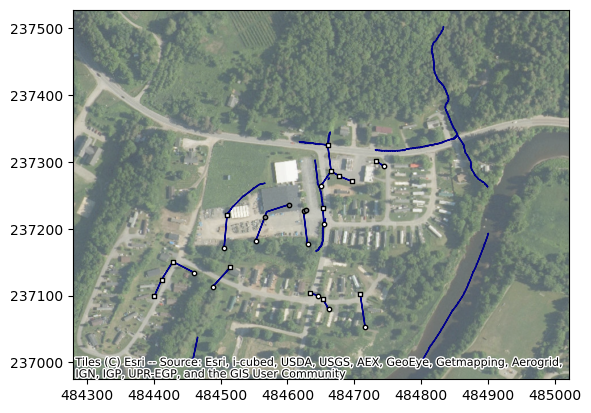

In [22]:
# This requires extra dependencies (matplotlib, contextily)

net.draw(add_basemap=True)

In [26]:
# preprocess_dem is just a utility function to prepare the DEM according to pyshed's
# standard process

grid, fdir, acc = preprocess_dem('../tests/test_data/johnson_vt/dem.tif')

# It's worth experimenting with this step to try and improve delineation results with
# your DEM. See pysheds documentation for more details

In [7]:
grid_epsg = 6589
delin = stormcatchments.Delineate(net, grid, fdir, acc, grid_epsg)

# (x, y) coordinates in same CRS as grid
pour_pt = (484636, 237170)
# get stormcatchment using the default accumulation threshold
stormcatchment = delin.get_stormcatchment(pour_pt, acc_thresh=1000)

In [10]:
catchment = stormcatchments.delineate.get_catchment(
  pour_pt, grid, fdir, acc, grid_epsg, acc_thresh=1000
)

<Axes: >

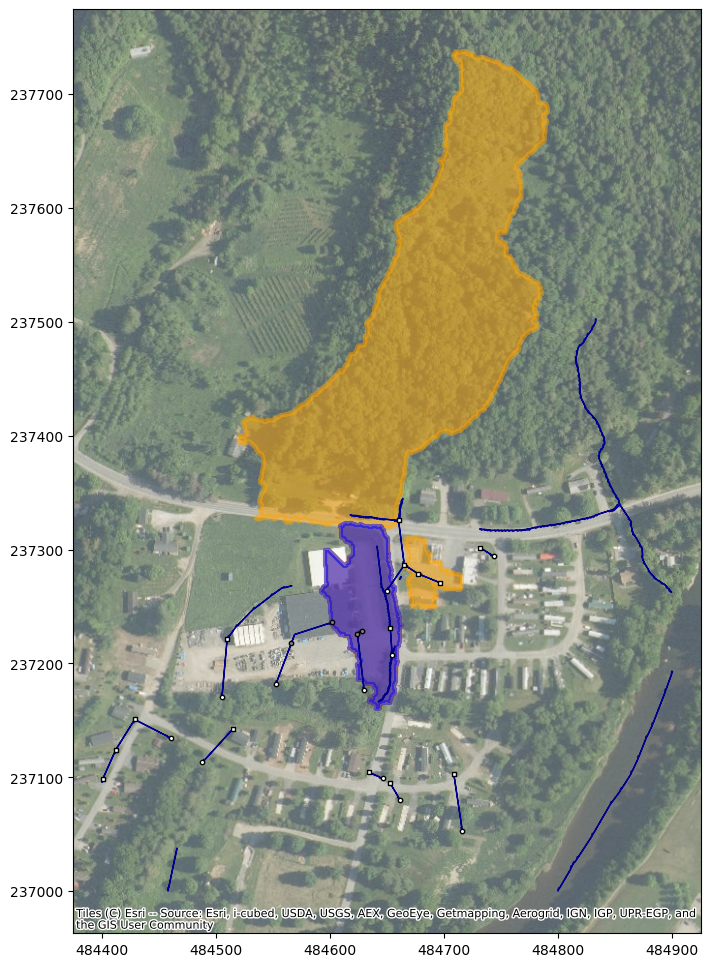

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))
stormcatchment.plot(ax=ax, ec='orange', fc='orange', alpha=0.5, linewidth=3)
catchment.plot(ax=ax, ec='blue', fc='blue', alpha=0.5, linewidth=3)
net.draw(ax=ax, add_basemap=True)